# 03 · Entrenamiento — Clustering (EDA de segmentación)
## Segmentación Inteligente de Pacientes — Programa de Medicina Funcional · Comfama

| | |
|---|---|
| **Propósito** | Responder la pregunta del EDA: *¿qué categorías/fenotipos emergen naturalmente de los datos?* Buscar el número de clusters (*k*) que mejor segmenta a la población y perfilar cada uno. |
| **Entrada** | `data/_processed/02_features.csv` |
| **Salida** | Selección de *k* y perfil de clusters (este notebook es exploratorio; el modelo final de clasificación por eje se entrena en el notebook 04). |

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path("..").resolve()))
from app.domain.ml_features import FEATURE_NAMES

PROCESSED_DIR = Path("../data/_processed")
df = pd.read_csv(PROCESSED_DIR / "02_features.csv")
X = df[FEATURE_NAMES].copy()
X = X.fillna(X.median(numeric_only=True))

scaler = StandardScaler()
Xs = scaler.fit_transform(X)
print(f"Filas: {len(df):,} | Features: {len(FEATURE_NAMES)}")


Filas: 16,174 | Features: 19


### Búsqueda de *k*
Se evalúa un `KMeans` conjunto (las 19 features) para *k* entre 2 y 8, con
inercia (codo) y silueta.

In [2]:
RANDOM_STATE = 42
results = []
for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(Xs)
    sil = silhouette_score(Xs, labels, sample_size=5000, random_state=RANDOM_STATE)
    results.append((k, km.inertia_, sil))

res_df = pd.DataFrame(results, columns=["k", "inercia", "silueta"])
res_df


,k,inercia,silueta
0,2,276660.244450,0.102537
1,3,253772.322383,0.143621
2,4,238889.317542,0.084739
3,5,224886.558423,0.096189
4,6,216979.095554,0.085446
5,7,207552.783136,0.092133
6,8,199686.344126,0.094420


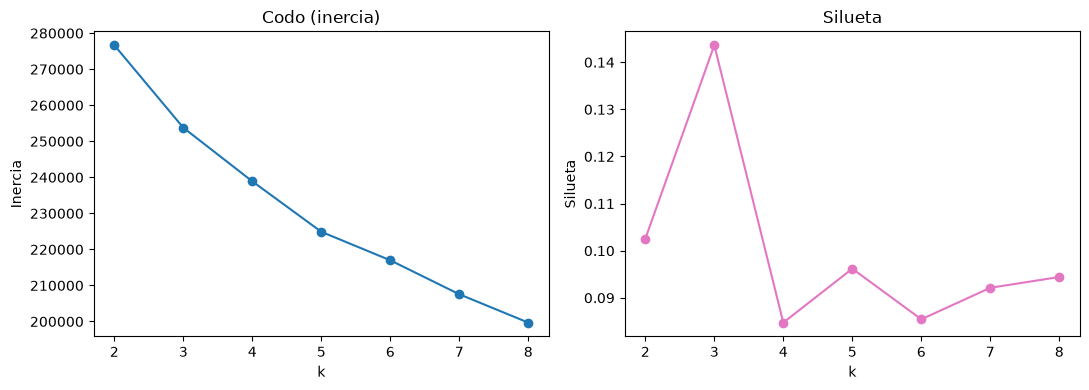


Mejor k por silueta: 3 (silueta=0.1436)


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(res_df["k"], res_df["inercia"], marker="o")
axes[0].set_title("Codo (inercia)")
axes[0].set_xlabel("k"); axes[0].set_ylabel("Inercia")
axes[1].plot(res_df["k"], res_df["silueta"], marker="o", color="tab:pink")
axes[1].set_title("Silueta")
axes[1].set_xlabel("k"); axes[1].set_ylabel("Silueta")
plt.tight_layout()
plt.savefig("../data/_processed/03_k_selection.png", dpi=110)
plt.show()

best_k = int(res_df.loc[res_df["silueta"].idxmax(), "k"])
print()
print(f"Mejor k por silueta: {best_k} (silueta={res_df['silueta'].max():.4f})")


**k=3 es el óptimo por silueta** entre 2 y 8 — y convenientemente coincide
con la taxonomía de negocio (Cardiometabólico / Digestivo / Mixto). Se
perfila k=3 a continuación.

In [4]:
km3 = KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init=10)
labels3 = km3.fit_predict(Xs)
sizes = pd.Series(labels3).value_counts().sort_index()
profile = df.assign(cluster=labels3).groupby("cluster")[FEATURE_NAMES].mean().round(2)
profile["n_pacientes"] = sizes
profile.T


cluster,0,1,2
imc,26.42,28.74,29.89
perimetro_abdominal,84.83,91.46,97.17
pa_sistolica,117.49,118.24,120.07
pa_diastolica,76.06,77.08,78.19
colesterol_total,198.50,195.01,176.17
colesterol_hdl,52.69,48.62,46.67
hba1c,5.39,5.48,6.35
usa_hipoglicemiante,0.00,0.00,0.98
usa_hipolipemiante,0.04,0.22,0.77
n_sintomas_gi,2.25,0.19,0.02


### Interpretación de los 3 clusters (categorías del EDA)

| Cluster | Tamaño | Rasgos distintivos | Categoría |
|---|---|---|---|
| El que tiene **`n_sintomas_gi` y `usa_antiacido_ibp` más altos** | ~22% | Síntomas gastrointestinales frecuentes, uso de antiácidos/IBP, alto estrés | **Digestivo** |
| El que tiene **`hba1c`, `usa_hipoglicemiante`, `usa_hipolipemiante`, IMC y perímetro más altos** | ~15% | Perfil metabólico de riesgo (posible diabetes/dislipidemia ya en tratamiento) | **Cardiometabólico** |
| El restante (mayoría) | ~63% | Sin síntomas digestivos relevantes ni marcadores cardiometabólicos muy elevados | **Bajo riesgo / sin eje predominante** |

**Hallazgo importante:** al repetir la búsqueda con k=4, 5 y 6 (ver celda
siguiente), **no emerge un cuarto cluster natural con ambos ejes elevados
simultáneamente** — lo que en k=3 parecía el cluster "del medio" es en
realidad población de bajo riesgo, no un grupo "Mixto". Esto es coherente
clínicamente (lo usual es que un paciente tenga predominantemente un eje
afectado) y tiene una implicación directa para el modelo de clasificación:
"Mixto" no se puede obtener como una etiqueta más de este clustering
conjunto — se deriva con un criterio explícito de "ambos ejes elevados
simultáneamente" en el notebook 04, no de un cluster propio.

In [5]:
for k in (4, 5, 6):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(Xs)
    profile_k = df.assign(cluster=labels).groupby(labels)[["n_sintomas_gi", "usa_hipoglicemiante", "imc"]].mean().round(2)
    profile_k["n"] = pd.Series(labels).value_counts().sort_index()
    print()
    print(f"=== k={k} ===")
    print(profile_k)



=== k=4 ===
   n_sintomas_gi  usa_hipoglicemiante    imc     n
0           2.41                 0.01  26.68  3069
1           0.27                 0.01  25.01  5690
2           0.02                 0.99  29.71  2271
3           0.22                 0.00  32.57  5144

=== k=5 ===
   n_sintomas_gi  usa_hipoglicemiante    imc     n
0           0.02                 0.99  29.70  2235
1           0.20                 0.01  25.11  5481
2           3.00                 0.00  26.14  2570
3           0.52                 0.05  28.66  1022
4           0.15                 0.00  32.62  4866



=== k=6 ===
   n_sintomas_gi  usa_hipoglicemiante    imc     n
0           0.37                 0.00  27.03  3212
1           0.18                 0.01  25.79  4626
2           3.07                 0.00  26.15  2352
3           0.12                 0.03  35.27  2825
4           0.02                 0.99  29.34  2149
5           0.52                 0.05  28.57  1010


---
**Resumen del notebook 03 (respuesta al EDA):** la población se segmenta
naturalmente en 3 categorías — **Digestivo** (síntomas GI + antiácidos),
**Cardiometabólico** (IMC/perímetro/HbA1c/medicación elevados) y un grupo de
**bajo riesgo** sin eje predominante — con silueta 0.144 (k=3, óptimo entre
2-8). No existe un cluster natural "Mixto"; esa categoría debe derivarse con
una regla explícita sobre puntajes por eje.
➡️ Continúa en **`04_perfilamiento_inferencia`** para el modelo de
clasificación final (dos K-Means por eje + regla de decisión) y su
integración con la app.